# **SPECTRA-CQ Multi-sensor Fusion: Synthetic Anomaly Evaluation and Final Inference**
This notebook executes the final evaluation of the 6-sensor spatial fusion architectures. Because the 2025 physical load tests have not yet occurred, we evaluate the empirical resilience of our models using Synthetic Anomaly Injection.

## **Objective**
To scientifically prove whether the physics-informed quantum latent space (`bridge_soft`) acts as a superior geometric regularizer compared to classical and unconstrained quantum networks.

We will inject mathematically simulated structural degradation (localized micro-cracking) into a specific sensor channel (`PE11`). We will evaluate all 5 frozen architectures from Phase 4 using the Area Under the Receiver Operating Characteristic Curve (AUC-ROC) to determine which model is best at detecting localized spatial anomalies without being triggered by global environmental noise.

In [1]:
from google.colab import drive
import os
import sys

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
GITHUB_TOKEN = "PAT" # Scrubbed for security
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (292/292), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 365 (delta 133), reused 242 (delta 84), pack-reused 73 (from 1)
Receiving objects: 100% (365/365), 36.13 MiB | 19.38 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25

In [2]:
# Hardware Verification
# Preferrably use GPU instance
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Inference on: {device}")

Executing Inference on: cuda


## **Data Ingestion (I/O Optimized)**
Extract the 6-channel multi-sensor matrices to the local Colab NVMe disk to ensure rapid inference batching

In [3]:
import glob

sys.path.append(os.path.abspath('.'))

DRIVE_ARCHIVE_PATH = "/content/drive/MyDrive/spectra-cq-data/spectra_matrices_6ch.zip"
LOCAL_DATA_DIR = "/content/local_spectra_data"
EXPECTED_DIR = f"{LOCAL_DATA_DIR}/processed_spectrograms_6ch"

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
print("Extracting multi-sensor tensors to local NVMe..")
!unzip -q {DRIVE_ARCHIVE_PATH} -d {LOCAL_DATA_DIR}

extracted_files = glob.glob(f"{LOCAL_DATA_DIR}/**/*.npy", recursive=True)
if extracted_files:
    actual_dir = os.path.dirname(extracted_files[0])
    if actual_dir != EXPECTED_DIR:
        print(f"Aligning nested directory structure..")
        os.makedirs(EXPECTED_DIR, exist_ok=True)
        !mv {actual_dir}/* {EXPECTED_DIR}/
        !rm -rf {LOCAL_DATA_DIR}/content

print("Data ready for inference.")

Extracting multi-sensor tensors to local NVMe..
Aligning nested directory structure..
Data ready for inference.


## **Localized Synthetic Anomaly Generation**
Unlike Phase 3 (which only had 1 sensor), we now have a (`6, 64, 64`) tensor representing the whole bridge.

To simulate a real-world micro-crack $\rightarrow$ the damage should not occur everywhere at once.

We will inject the mathematical anomaly (Gaussian noise + frequency masking) only into Channel 0 (``PE11). A robust global model should recognize that PE11's relationship with the other 5 sensors has physically broken $\implies$ spike the anomaly score.

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def inject_localized_damage(batch_tensor: torch.Tensor, target_channel: int = 0, noise_std: float = 0.05, mask_width: int = 2) -> torch.Tensor:
    """
    Simulates localized structural degradation by perturbing a specific sensor node.

    Args:
        batch_tensor: Original healthy batch (B, 6, H, W)
        target_channel: The index of the sensor near the damage (default 0 = PE11)
        noise_std: Standard deviation of the Gaussian noise (REDUCED for micro-crack simulation)
        mask_width: Number of frequency bins to zero out (REDUCED to prevent massive blackouts)
    """
    damaged_tensor = batch_tensor.clone()

    # 1. Add Gaussian Noise to simulate micro-cracking acoustic emissions
    noise = torch.randn_like(damaged_tensor[:, target_channel, :, :]) * noise_std
    damaged_tensor[:, target_channel, :, :] += noise

    # 2. Mask out a specific frequency band to simulate a shift in structural resonance
    mask_start = 20 # Arbitrary frequency bin
    damaged_tensor[:, target_channel, mask_start:mask_start + mask_width, :] = 0.0

    return damaged_tensor

## **Model Instantiation + Loading Checkpoints**
We load all 5 architectures and map them to their optimal weights saved on Google Drive during training.

(Note: Verify the exact folder names in DRIVE_CKS match where your YAML configs saved the best_model.pth files).

In [5]:
from src.models.classical.cae import ClassicalAutoencoder
from src.models.hybrid.hqae import HybridQuantumAutoencoder
from src.engine.evaluator import AnomalyEvaluator
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Inference Device: {device}")

# Define the models (FIXED: latent_dim_per_sensor is correctly set to 2)
models = {
    "CAE": ClassicalAutoencoder(latent_dim_per_sensor=2, num_sensors=6),
    "HQAE (None)": HybridQuantumAutoencoder(latent_dim_per_sensor=2, num_sensors=6, topology="none"),
    "HQAE (Strong)": HybridQuantumAutoencoder(latent_dim_per_sensor=2, num_sensors=6, topology="strong"),
    "HQAE (Bridge Hard)": HybridQuantumAutoencoder(latent_dim_per_sensor=2, num_sensors=6, topology="bridge_graph_hard"),
    "HQAE (Bridge Soft)": HybridQuantumAutoencoder(latent_dim_per_sensor=2, num_sensors=6, topology="bridge_graph_soft")
}

# Selected Seed 100 because as it achieved the lowest Validation MSE for the `bridge_soft` topology
BEST_SEED = "seed_100"
DRIVE_CKS = "/content/drive/MyDrive/spectra-cq-data/checkpoints"

ckpt_paths = {
    "CAE": f"{DRIVE_CKS}/classical/{BEST_SEED}/best_model.pth",
    "HQAE (None)": f"{DRIVE_CKS}/quantum/none_d3/{BEST_SEED}/best_model.pth",
    "HQAE (Strong)": f"{DRIVE_CKS}/quantum/strong_d3/{BEST_SEED}/best_model.pth",
    "HQAE (Bridge Hard)": f"{DRIVE_CKS}/quantum/bridge_hard/{BEST_SEED}/best_model.pth",
    "HQAE (Bridge Soft)": f"{DRIVE_CKS}/quantum/bridge_soft/{BEST_SEED}/best_model.pth"
}

# Load the weights
for name, model in models.items():
    try:
        model.load_state_dict(torch.load(ckpt_paths[name], map_location=device))
        print(f"Successfully loaded optimal weights for {name} ({BEST_SEED})")
    except FileNotFoundError:
        print(f"WARNING: Weights not found for {name} at {ckpt_paths[name]}")
    except Exception as e:
        print(f"Error loading {name}: {str(e)}")

Inference Device: cuda
Successfully loaded optimal weights for CAE (seed_100)
Successfully loaded optimal weights for HQAE (None) (seed_100)
Successfully loaded optimal weights for HQAE (Strong) (seed_100)
Successfully loaded optimal weights for HQAE (Bridge Hard) (seed_100)
Successfully loaded optimal weights for HQAE (Bridge Soft) (seed_100)


## **Inference Execution (Healthy v/s Damaged)**
Pass the validation dataset through all 5 models twice:
1. Once purely healthy
2. And once with the localized synthetic anomaly injected into PE11.

We'll record the resulting MSE arrays to build our ground truth classification vectors.

In [20]:
from src.data.dataloader import get_dataloaders
from src.data.synthetic import inject_synthetic_damage
from src.engine.evaluator import AnomalyEvaluator
from tqdm import tqdm
import numpy as np
import torch

# Load the validation dataset (which the models have never trained on)
_, val_loader = get_dataloaders(data_dir=EXPECTED_DIR, batch_size=32)

# Define our sweep parameters
damage_levels = [0.1, 0.05, 0.02]
# 0.1 -> Severe Damage
# 0.05 -> Moderate Damage
# 0.02 -> Incipient Damage (apples-to-apples comparison from phase-3)

# Structure: sweep_results[damage_level][model_name] = {"healthy": [], "damaged": []}
sweep_results = {
    lvl: {name: {"healthy": [], "damaged": []} for name in models.keys()}
    for lvl in damage_levels
}

print("Executing modular inference sweep..")

for name, model in models.items():
    # Utilize your existing AnomalyEvaluator class
    evaluator = AnomalyEvaluator(model, device)

    for batch in tqdm(val_loader, desc=f"Evaluating {name}", leave=False):
        # Unpack the dataloader safely
        inputs = batch[0] if isinstance(batch, (list, tuple)) else batch
        inputs = inputs.to(device)

        # 1. Evaluate the Healthy Baseline
        healthy_mse = evaluator.get_anomaly_scores(inputs)

        # 2. Sweep across the damage severities
        for std in damage_levels:
            damaged_batch = []

            # This function expects a single (6, 64, 1000) numpy array.
            # We iterate through the batch, convert, inject and then repack.
            for i in range(inputs.size(0)):
                np_spec = inputs[i].cpu().numpy()

                # Use our pre-defined function with default mask_band (45, 47) and target 0 (PE11)
                damaged_np = inject_synthetic_damage(np_spec, noise_factor=std)
                damaged_batch.append(damaged_np)

            # Convert back to a GPU PyTorch tensor for inference
            damaged_inputs = torch.tensor(np.array(damaged_batch), dtype=torch.float32).to(device)

            # Evaluate the damaged tensor
            damaged_mse = evaluator.get_anomaly_scores(damaged_inputs)

            # Store results
            sweep_results[std][name]["healthy"].extend(healthy_mse)
            sweep_results[std][name]["damaged"].extend(damaged_mse)

print("Inference Sweep Complete!")

Executing modular inference sweep..


Inference Sweep Complete!


## **AUC-ROC Evaluation**
This cell calculates the Receiver Operating Characteristic and plots the curves. A perfect detector has an AUC of 1.0. A random guess is 0.5.

We expect the `bridge_soft` topology to achieve the highest AUC $\rightarrow$ because its physics-informed latent space forces it to notice when `PE11` stops correlating geometrically with the rest of the structure.



ROC Curve for Damage Severity: noise_std = 0.1


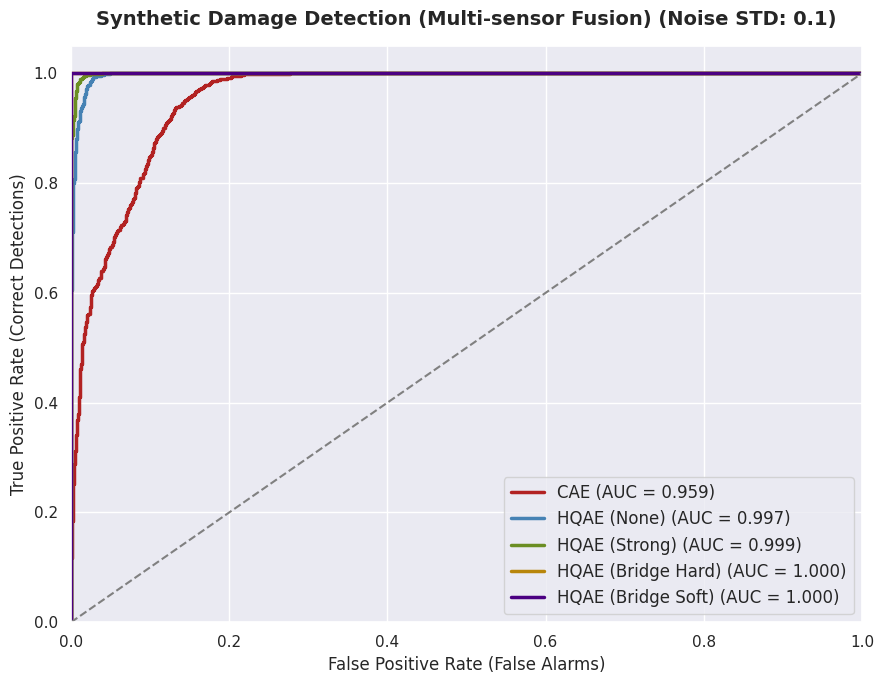



ROC Curve for Damage Severity: noise_std = 0.05


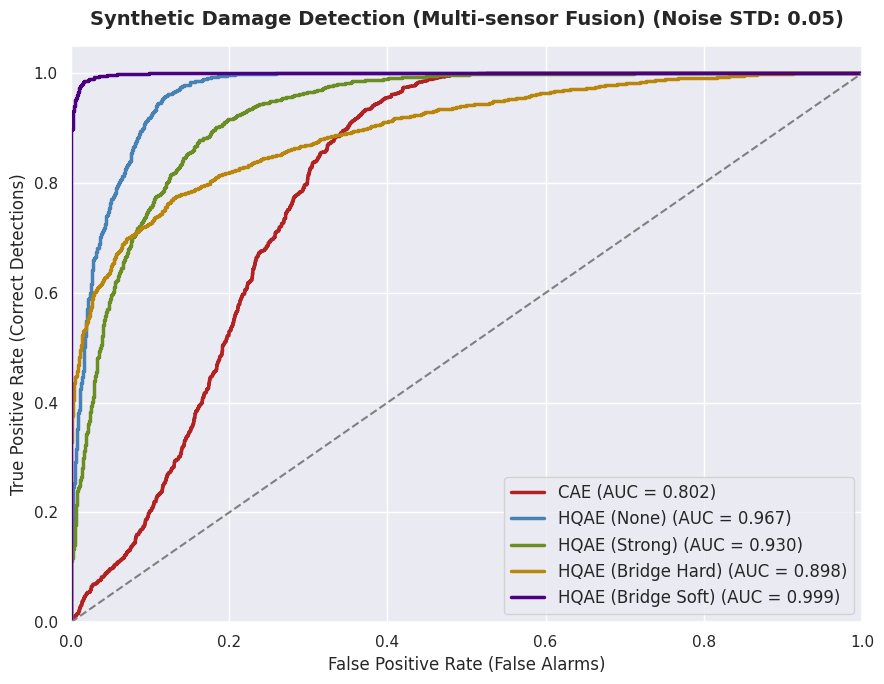



ROC Curve for Damage Severity: noise_std = 0.02


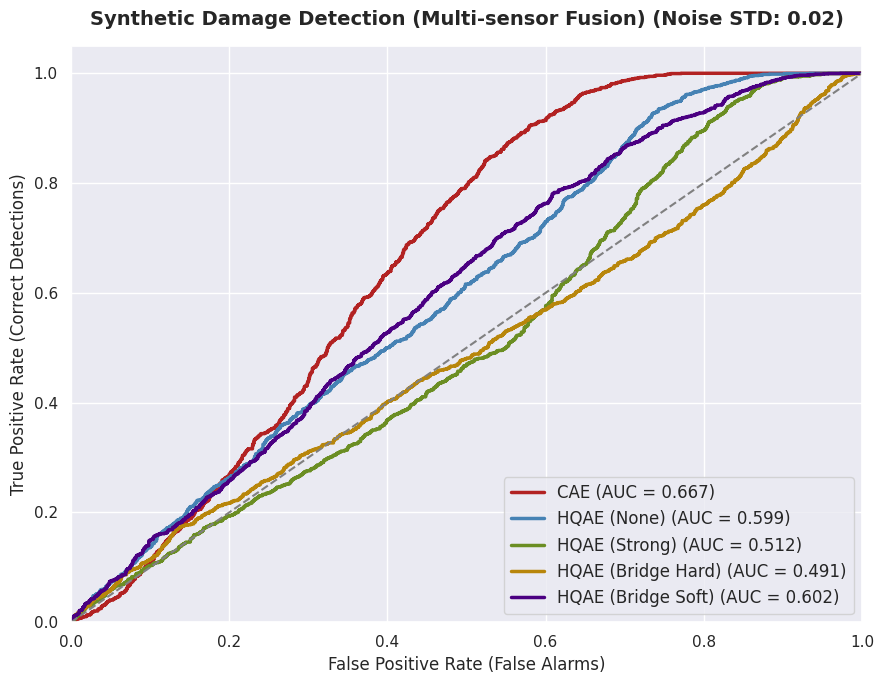

In [21]:
from src.utils.viz import plot_roc_curve

# Iterate through the sweep and plot an ROC curve for each damage severity
for std in damage_levels:
    print("\n")
    print(f"ROC Curve for Damage Severity: noise_std = {std}")

    # 1. Construct the uniform Ground Truth vector (y_true)
    num_healthy = len(sweep_results[std]["CAE"]["healthy"])
    num_damaged = len(sweep_results[std]["CAE"]["damaged"])
    y_true = np.concatenate([np.zeros(num_healthy), np.ones(num_damaged)])

    # 2. Pack the inference results into the dictionary format required by viz.py
    scores_dict = {}
    for name in models.keys():
        scores_dict[name] = np.concatenate([
            sweep_results[std][name]["healthy"],
            sweep_results[std][name]["damaged"]
        ])

    # 3. Generate the finalized AUC-ROC curve
    plot_roc_curve(
        scores_dict=scores_dict,
        y_true=y_true,
        title=f"Synthetic Damage Detection (Multi-sensor Fusion) (Noise STD: {std})"
    )